# Decision Tree: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Decision Tree** in Python.

### Concept Overview
Constructs sequential decision pathways splitting data on axis-aligned feature boundaries.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
\text{Gini Impurity: } G = 1 - \sum_{i=1}^c p_i^2 \quad \text{or Entropy: } H = -\sum_{i=1}^c p_i \log_2 p_i
$$

### Real-World Analogy
**Analogy:** Playing a game of 20 Questions, narrowing down the target category step-by-step.

### Worked Example
**Worked Example:** Classifying student job placement. If CGPA >= 7.5, go to next split (Internships). If Internships >= 1, predict placed (1), else predict unplaced (0).

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of student placement records
np.random.seed(42)
CGPA = np.random.uniform(5.5, 9.8, 500)
Internships = np.random.randint(0, 4, 500)
# Custom logic: placement likely with high CGPA + Internships
placed_probability = 1 / (1 + np.exp(-(2.5 * CGPA + 1.8 * Internships - 20)))
Placed = np.where(placed_probability > np.random.uniform(0, 1, 500), 1, 0)
df = pd.DataFrame({
    'CGPA': np.round(CGPA, 2),
    'Internships': Internships,
    'Placed': Placed
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (500, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CGPA         500 non-null    float64
 1   Internships  500 non-null    int64  
 2   Placed       500 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 11.8 KB
             CGPA  Internships      Placed
count  500.000000   500.000000  500.000000
mean     7.643480     1.386000    0.658000
std      1.284407     1.089669    0.474855
min      5.520000     0.000000    0.000000
25%      6.537500     0.000000    0.000000
50%      7.705000     1.000000    1.000000
75%      8.752500     2.000000    1.000000
max      9.770000     3.000000    1.000000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 CGPA           0
Internships    0
Placed         0
dtype: int64
Duplicate count: 54


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

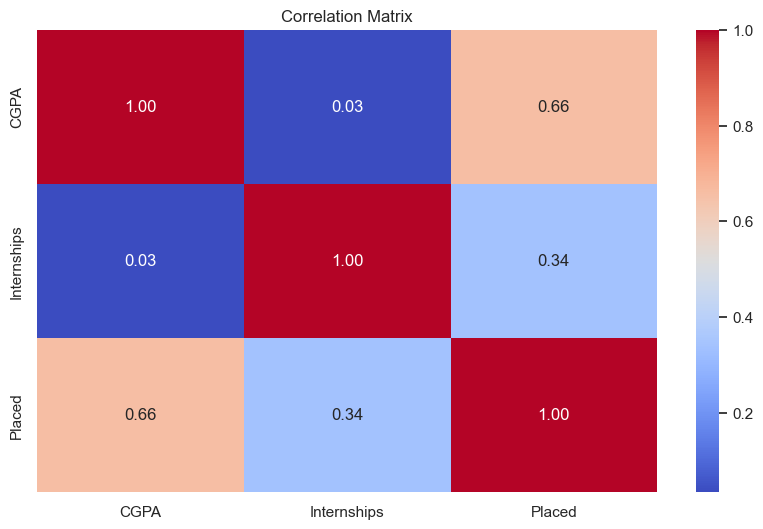

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (350, 2), Test size: (150, 2)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Decision Tree fit finished.")

Decision Tree fit finished.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

Accuracy: 0.8466666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.89      0.81        54
           1       0.93      0.82      0.87        96

    accuracy                           0.85       150
   macro avg       0.83      0.86      0.84       150
weighted avg       0.86      0.85      0.85       150



## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

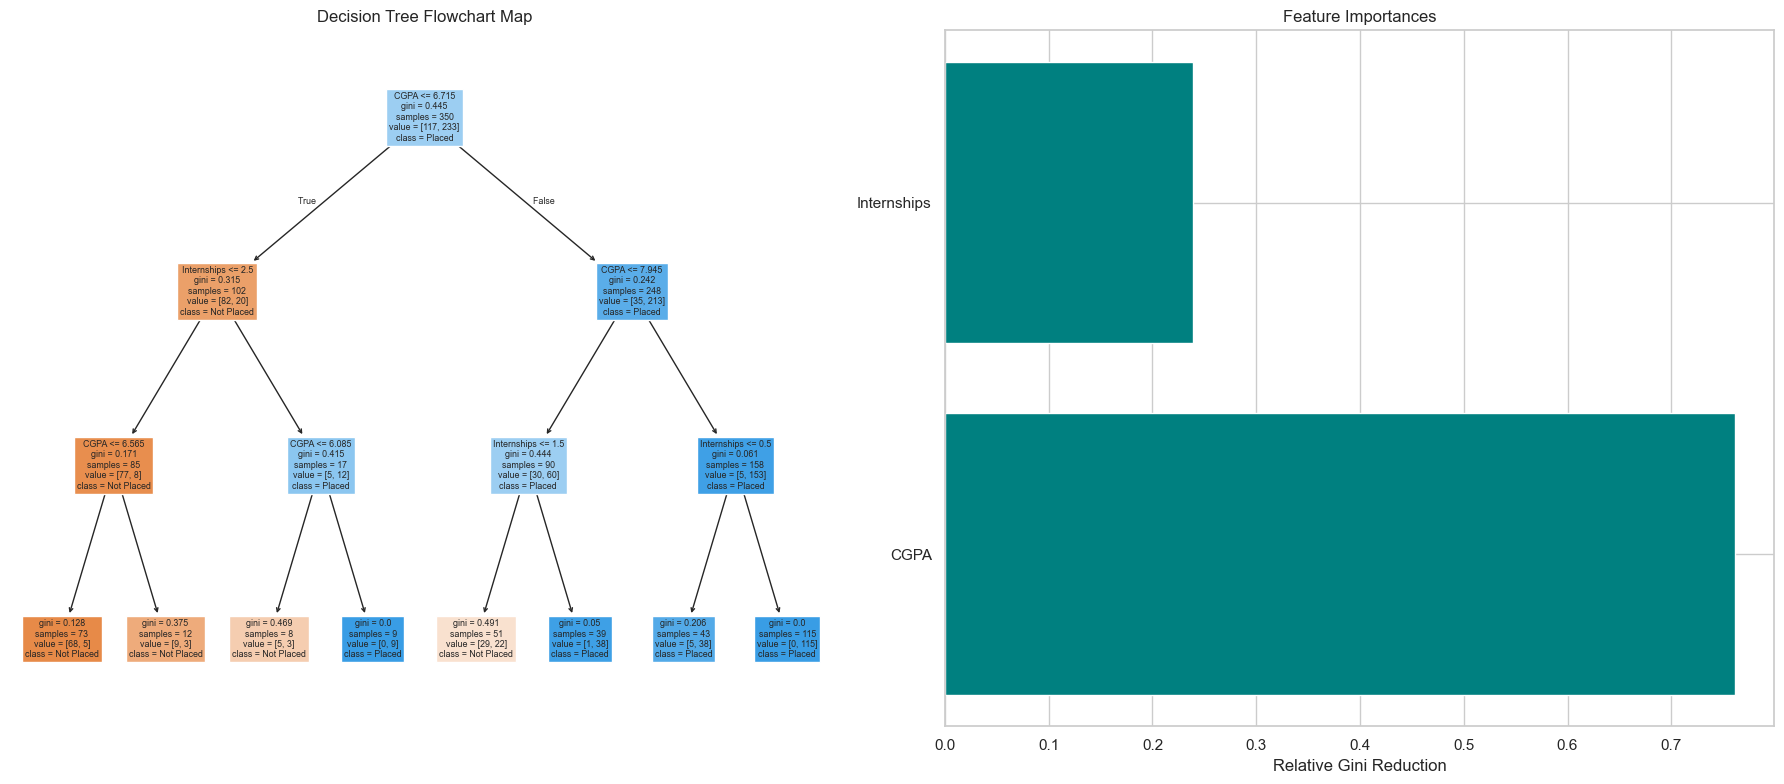

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# Plot 1: Visual Tree Diagram
plot_tree(model, feature_names=X.columns.tolist(), class_names=['Not Placed', 'Placed'], filled=True, ax=axes[0])
axes[0].set_title("Decision Tree Flowchart Map")

# Plot 2: Feature Importance
importances = model.feature_importances_
axes[1].barh(X.columns, importances, color='teal')
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Relative Gini Reduction")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What is Information Gain?**

*A: The reduction in entropy or impurity after a dataset partition split. Decision trees choose split criteria that maximize Information Gain.*

**Q2: How do you prevent Decision Trees from overfitting?**

*A: Use pruning parameters such as `max_depth` (limits tree growth), `min_samples_split`, or `min_samples_leaf`.*

**Q3: What are axis-aligned splits?**

*A: Decision trees split one feature at a time, creating boundaries that are perpendicular to the feature axes (rectangles/boxes).*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What impurity criterion is scikit-learn's default?**

*A: Gini Impurity (`gini`).*

**Q2: Does scaling affect Decision Trees?**

*A: No, scaling does not change feature order or threshold split choices, so trees are completely scale-invariant.*

**Q3: What does a leaf node represent?**

*A: A terminal node containing class predictions (no further splitting occurs).*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.